<a href="https://colab.research.google.com/github/rizmiya-gith/NorthStar-Analytics/blob/main/SQL_IN_R_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SECTION 1 — SQL IN R ANALYTICS

This section analyses NorthStar’s operational inefficiencies using SQL queries executed within R. The analysis focuses on delivery failures, customer complaints, route inefficiencies, hub performance, and driver incidents.

In [10]:
#Install Libraries
install.packages(c(
  "sqldf",
  "dplyr",
  "ggplot2",
  "lubridate",
  "tidyr",
  "scales",
  "reshape2"
  "dplyr"
))

ERROR: Error in parse(text = input): <text>:10:3: unexpected string constant
9:   "reshape2"
10:   "dplyr"
      ^


In [11]:
#Load Libraries
library(sqldf)
library(dplyr)
library(ggplot2)
library(lubridate)
library(tidyr)
library(scales)
library(reshape2)
library(dplyr)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [3]:
# The cleaned operational datasets are loaded directly from
# the GitHub repository. These datasets were preprocessed
# in a separate data-cleaning notebook to remove missing values,
# duplicates, and inconsistent operational records.
# Base GitHub URL containing cleaned NorthStar datasets
base_url <- "https://raw.githubusercontent.com/rizmiya-gith/NorthStar-Analytics/main/cleaned_data/"

In [4]:
# Load cleaned operational datasets into R data frames
deliveries <- read.csv(paste0(base_url, "deliveries_cleaned.csv"))

complaints <- read.csv(paste0(base_url, "complaints_cleaned.csv"))

customers <- read.csv(paste0(base_url, "customers_cleaned.csv"))

drivers <- read.csv(paste0(base_url, "drivers_cleaned.csv"))

hubs <- read.csv(paste0(base_url, "hubs_cleaned.csv"))

incidents <- read.csv(paste0(base_url, "incidents_cleaned.csv"))

orders <- read.csv(paste0(base_url, "orders_cleaned.csv"))

vehicles <- read.csv(paste0(base_url, "vehicles_cleaned.csv"))

app_events <- read.csv(paste0(base_url, "app_events_cleaned.csv"))

In [5]:
# Verify that all cleaned datasets loaded correctly
cat("Deliveries:", nrow(deliveries), "\n")
cat("Complaints:", nrow(complaints), "\n")
cat("Customers:", nrow(customers), "\n")
cat("Drivers:", nrow(drivers), "\n")
cat("Hubs:", nrow(hubs), "\n")
cat("Incidents:", nrow(incidents), "\n")
cat("Orders:", nrow(orders), "\n")
cat("Vehicles:", nrow(vehicles), "\n")
cat("App Events:", nrow(app_events), "\n")

Deliveries: 950 
Complaints: 320 
Customers: 650 
Drivers: 170 
Hubs: 8 
Incidents: 280 
Orders: 1250 
Vehicles: 120 
App Events: 640 


In [12]:
# FEATURE ENGINEERING

# Create binary target variable for delivery failure
deliveries$delivery_failed <- ifelse(
  deliveries$delivery_status == "Failed",
  1,
  0
)

# Create delay category for business analysis
deliveries$delay_category <- case_when(
  deliveries$delivery_status == "Failed" ~ "Failed",
  deliveries$delivery_status == "Delayed" ~ "Delayed",
  TRUE ~ "On Time"
)

table(deliveries$delay_category)


Delayed  Failed On Time 
    202     132     616 

In [13]:
# SQL SELECT — FAILED DELIVERIES
# Business Question:
# Which deliveries failed and what operational factors were involved?

failed_deliveries_sql <- sqldf("
  SELECT
    delivery_id,
    order_id,
    driver_id,
    hub_id,
    delivery_status,
    route_distance_km,
    manual_route_override_count,
    proof_of_completion_missing,
    customer_rating_post_delivery
  FROM deliveries
  WHERE delivery_status = 'Failed'
  ORDER BY customer_rating_post_delivery ASC
")

cat("Total failed deliveries:", nrow(failed_deliveries_sql), "\n")
head(failed_deliveries_sql, 10)

Total failed deliveries: 132 


,delivery_id,order_id,driver_id,hub_id,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>
1,DL00558,O00142,D024,H05,Failed,14.64,1,False,1.00
2,DL00536,O01184,D055,H01,Failed,7.04,2,False,1.07
3,DL00057,O00921,D141,H04,Failed,10.91,0,False,1.22
4,DL00862,O00031,D165,H01,Failed,8.40,1,False,1.41
5,DL00187,O00439,D111,H05,Failed,17.61,1,False,1.53
6,DL00839,O00566,D078,H03,Failed,7.89,2,True,1.65
7,DL00783,O00380,D099,H07,Failed,8.95,2,True,1.67
8,DL00040,O00919,D027,H04,Failed,9.53,1,False,1.68
9,DL00694,O00457,D087,H05,Failed,14.66,0,True,1.68


### Business Interpretation

Failed deliveries directly affect customer satisfaction and operational efficiency. Analysing failed deliveries helps NorthStar identify whether service failures are linked to route distance, manual route overrides, driver performance, or missing proof of completion.

In [14]:
#SQL JOIN — hub performance
# =============================================================================
# SQL JOIN — HUB FAILURE RATE ANALYSIS
# =============================================================================

# Business Question:
# Which hubs have the highest delivery failure rate?

hub_failures_sql <- sqldf("
  SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    h.hub_type,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_count,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_count,
    SUM(CASE WHEN d.delivery_status = 'OnTime' THEN 1 ELSE 0 END) AS ontime_count,
    ROUND(
      100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
      / COUNT(d.delivery_id), 2
    ) AS failure_rate_pct
  FROM hubs h
  JOIN deliveries d ON h.hub_id = d.hub_id
  GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type
  ORDER BY failure_rate_pct DESC
")

hub_failures_sql

hub_id,hub_name,zone,hub_type,total_deliveries,failed_count,delayed_count,ontime_count,failure_rate_pct
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>
H08,Midtown Relay,CENTRAL,Charging,128,26,22,80,20.31
H05,Central Core,CENTRAL,Control,115,23,25,67,20.00
H06,Airport Hub,AIRPORT,Dispatch,104,15,27,62,14.42
H04,West Gate,WEST,Dispatch,127,16,28,83,12.60
H01,North Exchange,NORTH,Dispatch,136,17,26,93,12.50
H07,Riverside Hub,RIVERSIDE,Warehouse,115,14,25,76,12.17
H02,South Link,SOUTH,Dispatch,106,10,26,70,9.43
H03,East Dock,EAST,Warehouse,119,11,23,85,9.24


### Business Interpretation

This query identifies underperforming hubs by comparing failure rates across locations. Hubs with high failure rates may indicate staffing problems, route allocation issues, dispatch inefficiency, or local operational bottlenecks.

In [15]:
# SQL aggregation — complaints
# SQL AGGREGATION — COMPLAINT ANALYSIS
# =============================================================================

# Business Question:
# Which complaint types are most frequent and costly?

complaint_analysis_sql <- sqldf("
  SELECT
    complaint_type,
    channel,
    COUNT(*) AS complaint_count,
    ROUND(AVG(resolution_days), 1) AS avg_resolution_days,
    ROUND(AVG(compensation_amount), 2) AS avg_compensation,
    SUM(compensation_amount) AS total_compensation,
    SUM(CASE WHEN status = 'Open' THEN 1 ELSE 0 END) AS still_open
  FROM complaints
  GROUP BY complaint_type, channel
  ORDER BY complaint_count DESC
")

complaint_analysis_sql

complaint_type,channel,complaint_count,avg_resolution_days,avg_compensation,total_compensation,still_open
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>
Delay,App,31,7.8,18.60,576.60,8
Delay,Chatbot,25,6.4,17.12,427.98,3
Delay,Phone,24,6.4,16.33,391.97,3
Delay,Email,21,8.4,14.30,300.29,3
MissedPickup,App,20,7.9,22.05,440.94,1
MissedPickup,Phone,19,6.2,18.83,357.75,8
DriverBehaviour,Phone,18,8.3,20.64,371.53,5
AppIssue,Email,15,8.3,18.10,271.52,1
AppIssue,App,14,7.9,18.05,252.76,3


### Business Interpretation

Complaint analysis helps identify the main causes of customer dissatisfaction. High complaint counts and compensation values show where poor service performance is creating financial and reputational impact.

In [16]:
# SQL JOIN — driver incidents
# SQL JOIN — DRIVER INCIDENT ANALYSIS
# =============================================================================

# Business Question:
# Which drivers are associated with the highest number of incidents?

driver_incidents_sql <- sqldf("
  SELECT
    dr.driver_id,
    dr.base_zone,
    dr.employment_type,
    dr.driver_rating,
    dr.training_score,
    COUNT(i.incident_id) AS total_incidents,
    SUM(CASE WHEN i.severity IN ('High','Critical') THEN 1 ELSE 0 END) AS high_severity_incidents,
    ROUND(AVG(i.resolved_hours), 1) AS avg_resolution_hours
  FROM drivers dr
  JOIN deliveries d ON dr.driver_id = d.driver_id
  JOIN incidents i ON d.delivery_id = i.delivery_id
  GROUP BY dr.driver_id, dr.base_zone, dr.employment_type,
           dr.driver_rating, dr.training_score
  ORDER BY total_incidents DESC
  LIMIT 10
")

driver_incidents_sql

driver_id,base_zone,employment_type,driver_rating,training_score,total_incidents,high_severity_incidents,avg_resolution_hours
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>
D039,AIRPORT,Contract,4.06,86.10000,7,1,17.2
D087,NORTH,Contract,4.43,73.30000,6,1,4.9
D004,AIRPORT,PartTime,4.75,88.90000,5,3,6.0
D026,NORTH,PartTime,3.15,84.90000,5,3,16.2
D132,SOUTH,Contract,4.20,77.60000,5,1,11.6
D146,AIRPORT,Contract,4.36,74.91472,5,1,15.8
D002,CENTRAL,FullTime,3.94,42.40000,4,4,14.0
D032,EAST,PartTime,3.99,81.50000,4,0,9.5
D037,NORTH,PartTime,4.67,63.90000,4,2,9.4


### Business Interpretation

Drivers with repeated incidents represent operational risk. This analysis supports targeted driver training, supervision, and risk monitoring.

In [17]:
# SQL JOIN — route overrides
# SQL JOIN — ROUTE OVERRIDE ANALYSIS
# =============================================================================

# Business Question:
# Which routes show the highest manual route override activity?

route_override_sql <- sqldf("
  SELECT
    o.pickup_zone,
    o.dropoff_zone,
    o.service_type,
    COUNT(d.delivery_id) AS total_routes,
    SUM(d.manual_route_override_count) AS total_overrides,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides_per_route,
    ROUND(AVG(d.route_distance_km), 1) AS avg_distance_km,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failures
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone, o.dropoff_zone, o.service_type
  ORDER BY avg_overrides_per_route DESC
  LIMIT 15
")

route_override_sql

pickup_zone,dropoff_zone,service_type,total_routes,total_overrides,avg_overrides_per_route,avg_distance_km,avg_cost,failures
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>
AIRPORT,CTR,Retail,1,4,4.00,33.7,13.79,0
AIRPORT,SOUTH,Business,2,8,4.00,27.9,19.70,1
AIRPORT,CENTRAL,Parcel,1,3,3.00,24.6,18.25,0
AIRPORT,NORTH,Medical,2,6,3.00,25.7,15.64,0
CENTRAL,CTR,Medical,1,3,3.00,18.7,12.76,1
CENTRAL,NORTH,Business,1,3,3.00,13.0,12.99,0
RIVERSIDE,AIRPORT,Passenger,1,3,3.00,10.8,11.92,0
AIRPORT,CENTRAL,Passenger,4,11,2.75,28.6,15.20,0
AIRPORT,SOUTH,Parcel,5,13,2.60,29.7,16.76,0


### Business Interpretation

Manual route overrides may indicate poor route planning, traffic issues, or drivers avoiding assigned routes. Routes with high override frequency should be reviewed for optimisation.

In [18]:
# =============================================================================
# SQL CRUD — INSERT
# =============================================================================

# Business Context:
# A new customer complaint is logged into a working copy of the complaints table.

complaints_working <- complaints

new_complaint <- data.frame(
  complaint_id = "CP9999",
  customer_id = "C0001",
  order_id = "O00100",
  complaint_type = "Delay",
  channel = "App",
  severity = "High",
  created_at = "2026-01-15 09:30:00",
  status = "Open",
  resolution_days = NA,
  compensation_amount = NA
)

complaints_working <- rbind(complaints_working, new_complaint)

sqldf("
  SELECT *
  FROM complaints_working
  WHERE complaint_id = 'CP9999'
")

complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
CP9999,C0001,O00100,Delay,App,High,2026-01-15 09:30:00,Open,NA,NA


In [19]:
# =============================================================================
# SQL CRUD — UPDATE
# =============================================================================

# Business Context:
# Open complaints are escalated for faster resolution.

complaints_working$status <- ifelse(
  complaints_working$complaint_id == "CP9999",
  "Escalated",
  complaints_working$status
)

sqldf("
  SELECT complaint_id, status
  FROM complaints_working
  WHERE complaint_id = 'CP9999'
")

complaint_id,status
<chr>,<chr>
CP9999,Escalated


In [20]:
# =============================================================================
# SQL CRUD — DELETE
# =============================================================================

# Business Context:
# The test complaint record is removed after CRUD demonstration.

before_delete <- nrow(complaints_working)

complaints_working <- sqldf("
  SELECT *
  FROM complaints_working
  WHERE complaint_id != 'CP9999'
")

after_delete <- nrow(complaints_working)

cat("Records before delete:", before_delete, "\n")
cat("Records after delete:", after_delete, "\n")
cat("Records removed:", before_delete - after_delete, "\n")

Records before delete: 321 
Records after delete: 320 
Records removed: 1 


In [21]:
# =============================================================================
# DATA MANIPULATION AND TRANSFORMATION IN R
# =============================================================================

hub_summary <- deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  group_by(hub_id, hub_name, zone) %>%
  summarise(
    total_deliveries = n(),
    failed_deliveries = sum(delivery_failed),
    failure_rate = round(mean(delivery_failed) * 100, 2),
    avg_rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    avg_overrides = round(mean(manual_route_override_count, na.rm = TRUE), 2),
    avg_cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate))

hub_summary

hub_id,hub_name,zone,total_deliveries,failed_deliveries,failure_rate,avg_rating,avg_overrides,avg_cost
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
H08,Midtown Relay,CENTRAL,128,26,20.31,3.88,1.11,11.71
H05,Central Core,CENTRAL,115,23,20.00,3.67,0.95,13.69
H06,Airport Hub,AIRPORT,104,15,14.42,3.88,0.91,13.32
H04,West Gate,WEST,127,16,12.60,3.92,0.87,13.17
H01,North Exchange,NORTH,136,17,12.50,3.84,1.03,12.76
H07,Riverside Hub,RIVERSIDE,115,14,12.17,3.88,1.05,12.92
H02,South Link,SOUTH,106,10,9.43,3.95,0.92,12.56
H03,East Dock,EAST,119,11,9.24,3.90,0.89,12.74


### Business Interpretation

This transformed summary compares hubs using failure rate, customer rating, route overrides, and operating cost. It supports management decisions about which hubs require operational improvement.

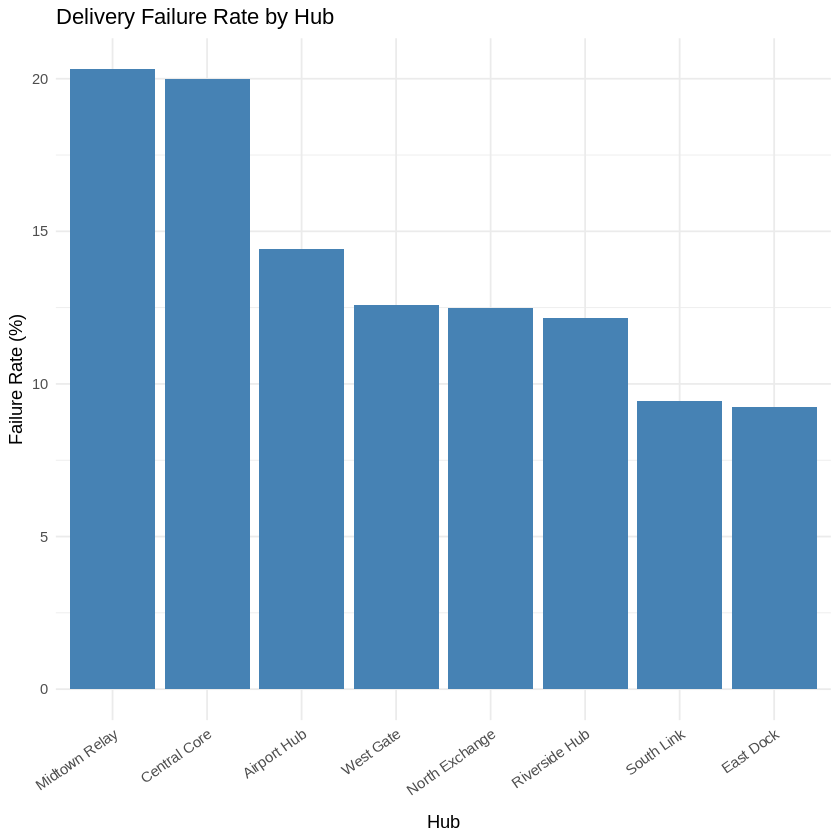

In [22]:
# =============================================================================
# VISUAL 1 — HUB FAILURE RATE
# =============================================================================

ggplot(hub_summary,
       aes(x = reorder(hub_name, -failure_rate),
           y = failure_rate)) +
  geom_col(fill = "steelblue") +
  theme_minimal() +
  labs(
    title = "Delivery Failure Rate by Hub",
    x = "Hub",
    y = "Failure Rate (%)"
  ) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

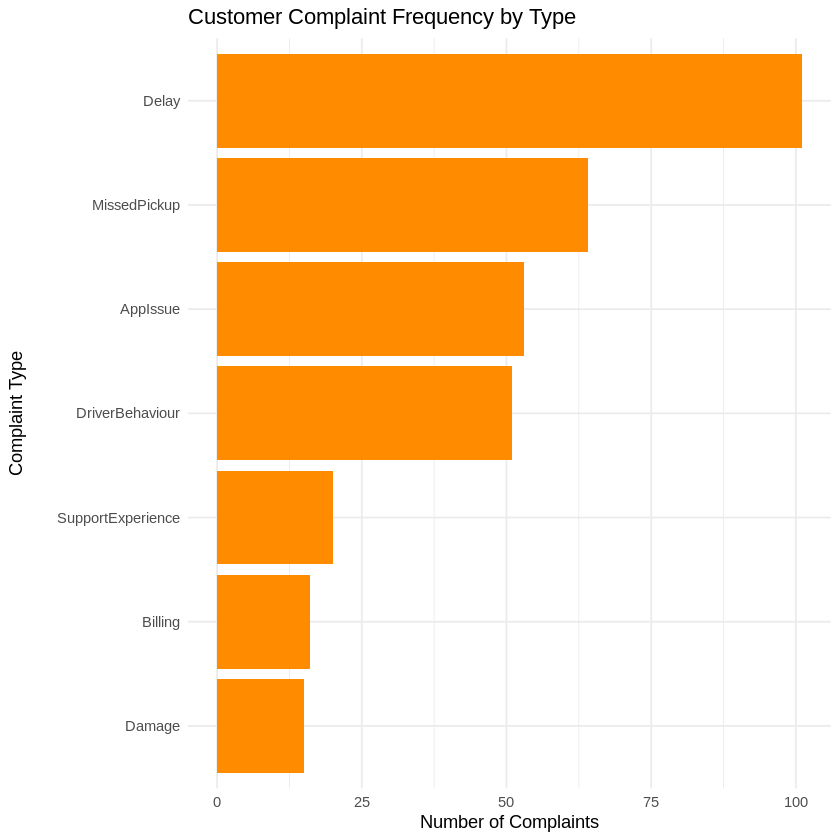

In [23]:
# =============================================================================
# VISUAL 2 — COMPLAINT TYPE FREQUENCY
# =============================================================================

complaint_counts <- complaints %>%
  group_by(complaint_type) %>%
  summarise(count = n(), .groups = "drop") %>%
  arrange(desc(count))

ggplot(complaint_counts,
       aes(x = reorder(complaint_type, count),
           y = count)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Customer Complaint Frequency by Type",
    x = "Complaint Type",
    y = "Number of Complaints"
  )

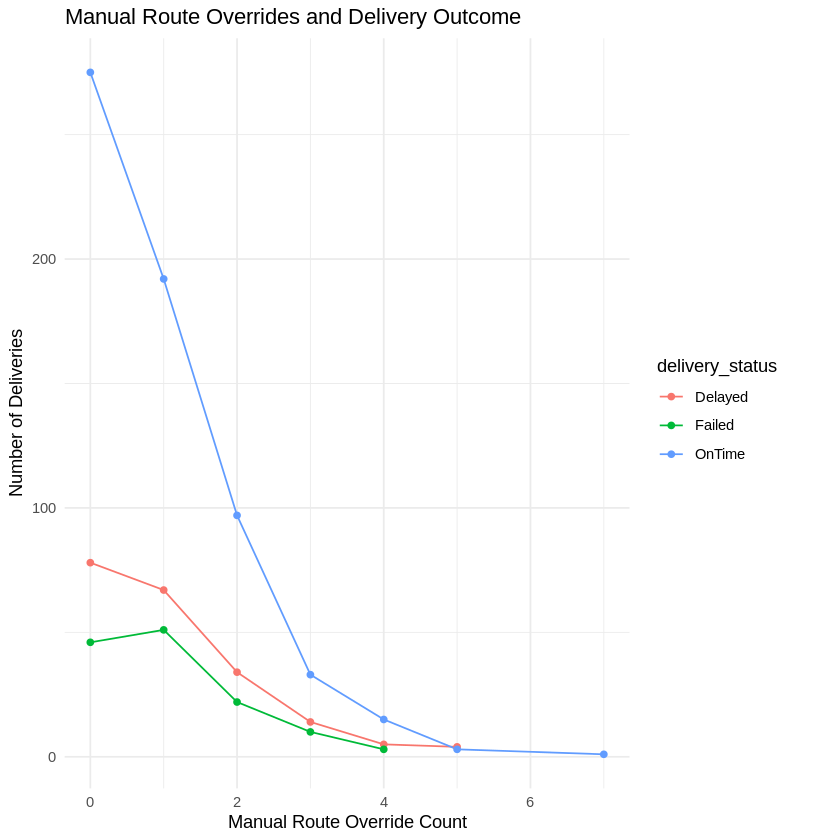

In [24]:
# =============================================================================
# VISUAL 4 — MANUAL ROUTE OVERRIDES BY DELIVERY STATUS
# =============================================================================

override_summary <- deliveries %>%
  group_by(manual_route_override_count, delivery_status) %>%
  summarise(count = n(), .groups = "drop")

ggplot(override_summary,
       aes(x = manual_route_override_count,
           y = count,
           colour = delivery_status)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    title = "Manual Route Overrides and Delivery Outcome",
    x = "Manual Route Override Count",
    y = "Number of Deliveries"
  )

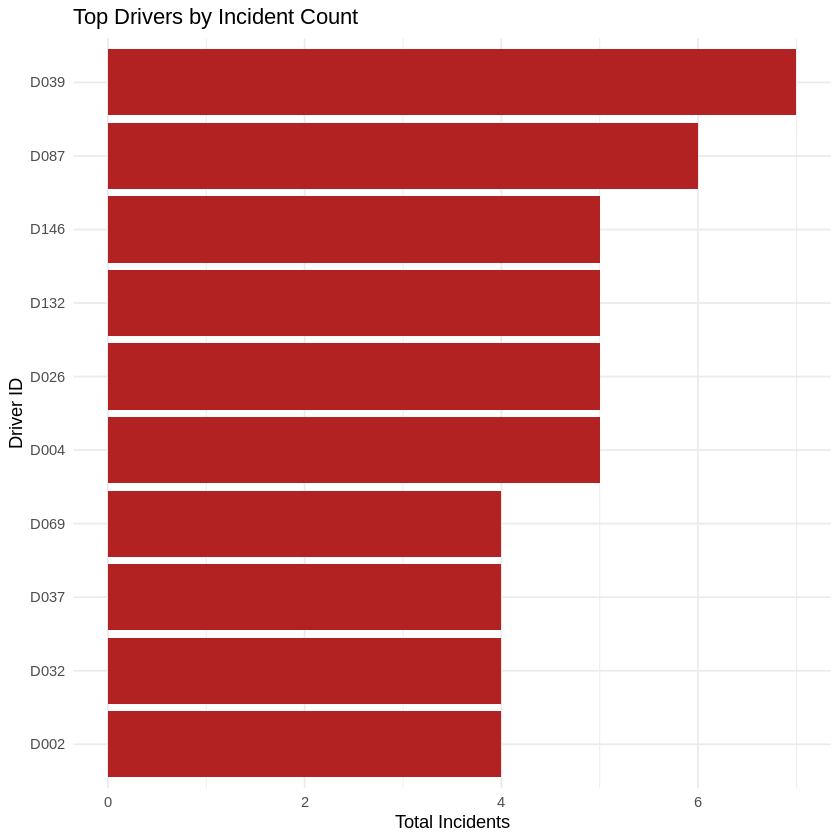

In [25]:
# =============================================================================
# VISUAL 5 — TOP HIGH-INCIDENT DRIVERS
# =============================================================================

ggplot(driver_incidents_sql,
       aes(x = reorder(driver_id, total_incidents),
           y = total_incidents)) +
  geom_col(fill = "firebrick") +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Top Drivers by Incident Count",
    x = "Driver ID",
    y = "Total Incidents"
  )

In [26]:
# =============================================================================
# SECTION 1 BUSINESS SUMMARY
# =============================================================================

cat("SECTION 1 KEY FINDINGS\n")
cat("1. Hub failure rates reveal location-specific operational inefficiencies.\n")
cat("2. Complaint analysis shows the major causes of customer dissatisfaction.\n")
cat("3. Driver incident analysis identifies operational risk areas.\n")
cat("4. Manual route overrides suggest route planning inefficiencies.\n")
cat("5. Failed or delayed deliveries reduce customer ratings and service quality.\n")

SECTION 1 KEY FINDINGS
1. Hub failure rates reveal location-specific operational inefficiencies.
2. Complaint analysis shows the major causes of customer dissatisfaction.
3. Driver incident analysis identifies operational risk areas.
4. Manual route overrides suggest route planning inefficiencies.
5. Failed or delayed deliveries reduce customer ratings and service quality.


In [27]:
# =============================================================================
# HUB PERFORMANCE KPI SUMMARY
# =============================================================================

hub_kpis <- deliveries %>%
  group_by(hub_id) %>%
  summarise(
    total_deliveries = n(),
    failed_deliveries = sum(delivery_failed),
    failure_rate = round(mean(delivery_failed) * 100, 2),
    avg_customer_rating =
      round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    avg_route_overrides =
      round(mean(manual_route_override_count, na.rm = TRUE), 2),
    avg_delivery_cost =
      round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate))

hub_kpis

hub_id,total_deliveries,failed_deliveries,failure_rate,avg_customer_rating,avg_route_overrides,avg_delivery_cost
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
H08,128,26,20.31,3.88,1.11,11.71
H05,115,23,20.00,3.67,0.95,13.69
H06,104,15,14.42,3.88,0.91,13.32
H04,127,16,12.60,3.92,0.87,13.17
H01,136,17,12.50,3.84,1.03,12.76
H07,115,14,12.17,3.88,1.05,12.92
H02,106,10,9.43,3.95,0.92,12.56
H03,119,11,9.24,3.90,0.89,12.74


In [28]:
# =============================================================================
# CUSTOMER SATISFACTION RISK ANALYSIS
# =============================================================================

customer_risk_analysis <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(
    avg_rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    avg_overrides = round(mean(manual_route_override_count, na.rm = TRUE), 2),
    avg_distance = round(mean(route_distance_km, na.rm = TRUE), 2),
    avg_cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    total = n(),
    .groups = "drop"
  )

customer_risk_analysis

delivery_status,avg_rating,avg_overrides,avg_distance,avg_cost,total
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Delayed,3.13,1.07,14.67,13.14,202
Failed,3.06,1.04,13.37,13.15,132
OnTime,4.28,0.92,13.78,12.68,616


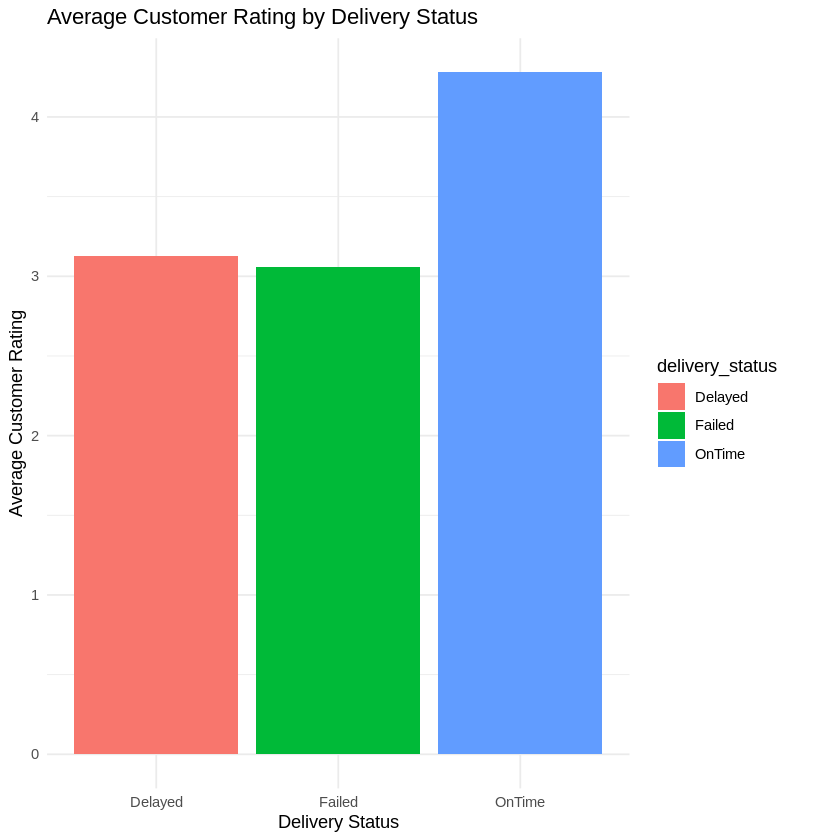

In [29]:
ggplot(customer_risk_analysis,
       aes(x = delivery_status,
           y = avg_rating,
           fill = delivery_status)) +
  geom_col() +
  theme_minimal() +
  labs(
    title = "Average Customer Rating by Delivery Status",
    x = "Delivery Status",
    y = "Average Customer Rating"
  )

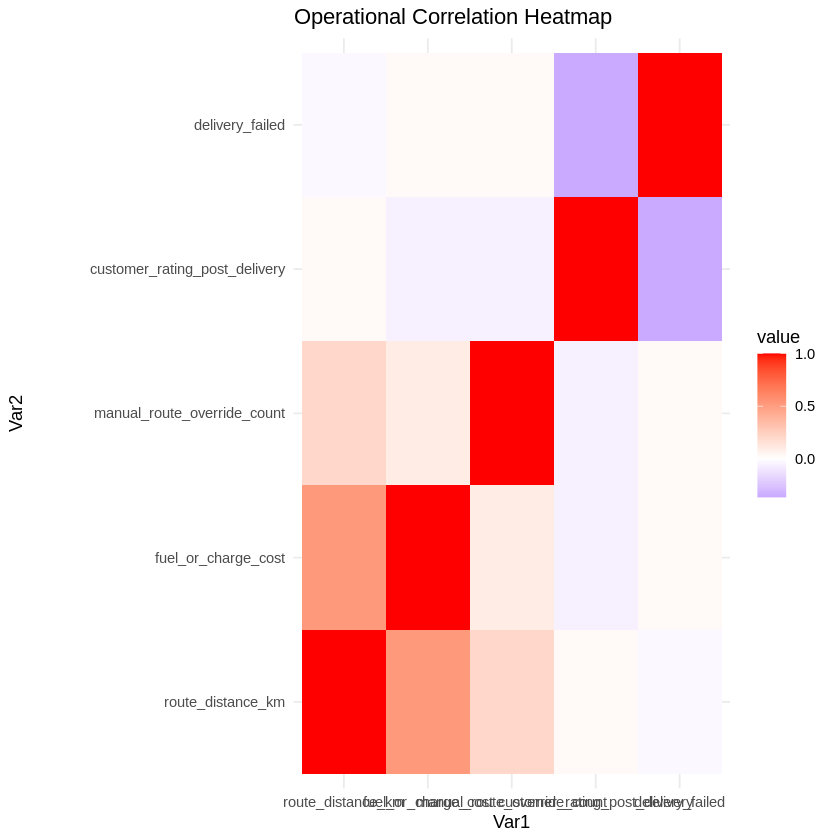

In [30]:
# =============================================================================
# CORRELATION HEATMAP
# =============================================================================

numeric_delivery <- deliveries %>%
  select(
    route_distance_km,
    fuel_or_charge_cost,
    manual_route_override_count,
    customer_rating_post_delivery,
    delivery_failed
  )

cor_matrix <- cor(
  numeric_delivery,
  use = "complete.obs"
)

melted_cor <- melt(cor_matrix)

ggplot(melted_cor,
       aes(x = Var1,
           y = Var2,
           fill = value)) +
  geom_tile() +
  scale_fill_gradient2(
    low = "blue",
    high = "red",
    mid = "white",
    midpoint = 0
  ) +
  theme_minimal() +
  labs(title = "Operational Correlation Heatmap")

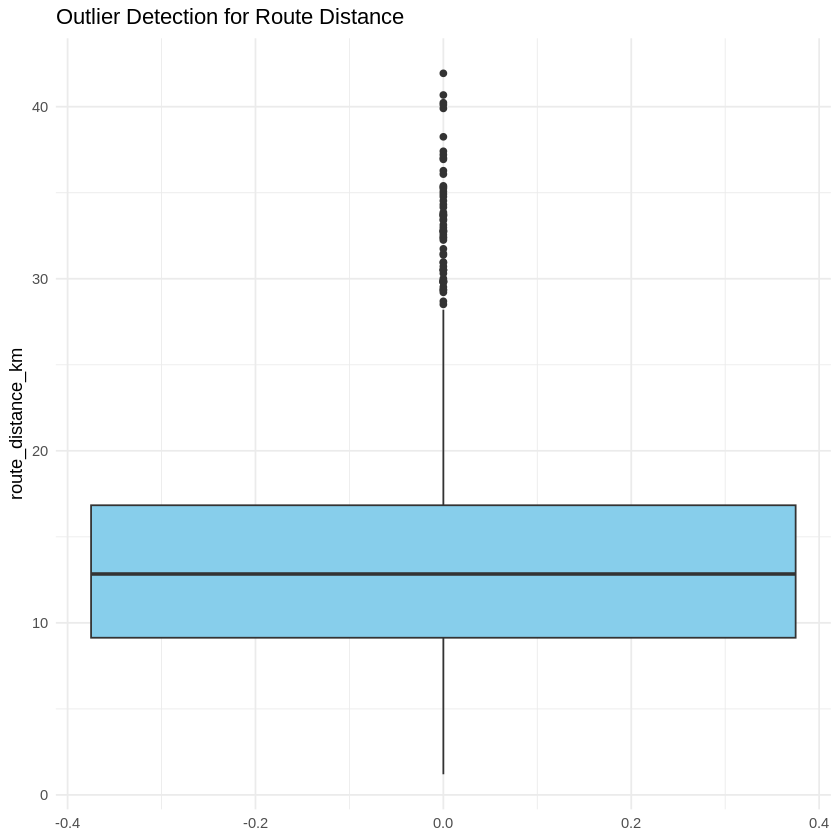

In [31]:
# =============================================================================
# OUTLIER DETECTION — ROUTE DISTANCE
# =============================================================================

ggplot(deliveries,
       aes(y = route_distance_km)) +
  geom_boxplot(fill = "skyblue") +
  theme_minimal() +
  labs(
    title = "Outlier Detection for Route Distance"
  )

In [33]:
# =============================================================================
# INCIDENT SEVERITY ANALYSIS
# =============================================================================

incident_severity <- incidents %>%
  group_by(severity) %>%
  summarise(
    total_incidents = n(),
    avg_resolution_hours =
      round(mean(resolved_hours, na.rm = TRUE), 2),
    .groups = "drop"
  )

incident_severity

severity,total_incidents,avg_resolution_hours
<chr>,<int>,<dbl>
Critical,27,11.44
High,68,11.15
Low,79,13.58
Medium,106,11.47


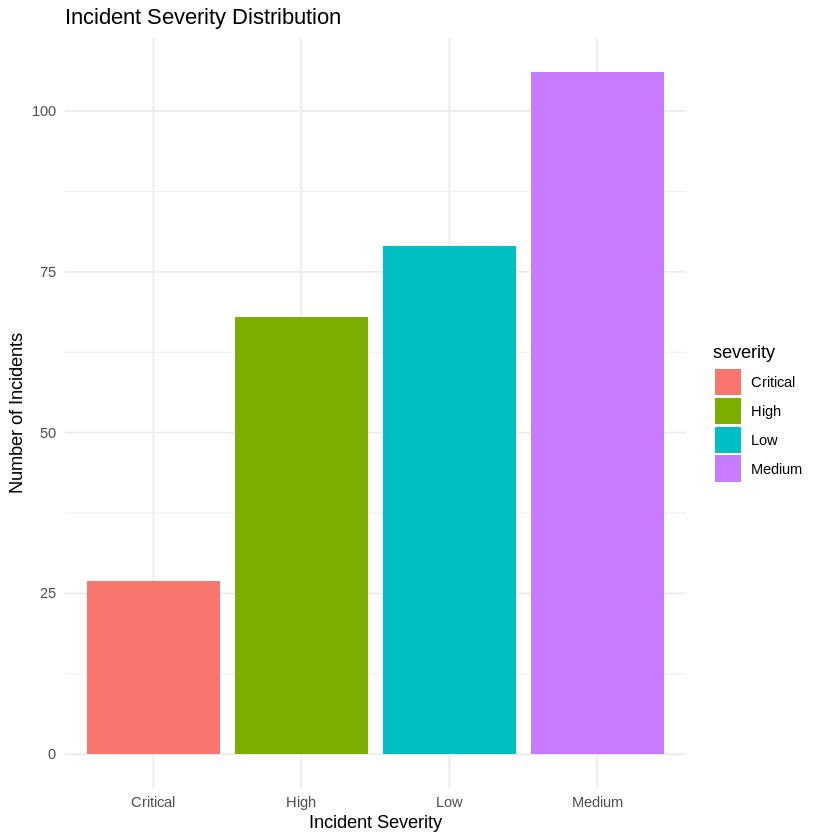

In [34]:
ggplot(incident_severity,
       aes(x = severity,
           y = total_incidents,
           fill = severity)) +
  geom_col() +
  theme_minimal() +
  labs(
    title = "Incident Severity Distribution",
    x = "Incident Severity",
    y = "Number of Incidents"
  )